In [1]:
!pip install opencv-python

Using: 251030_CMCH_swelling_PARAFFIN_Sample1_0006_Mode2D 7h59.tiff
Hydrogel thickness px: 109 | Upper px: 54
Upper porosity (2D) = 11.72% | pores count = 71


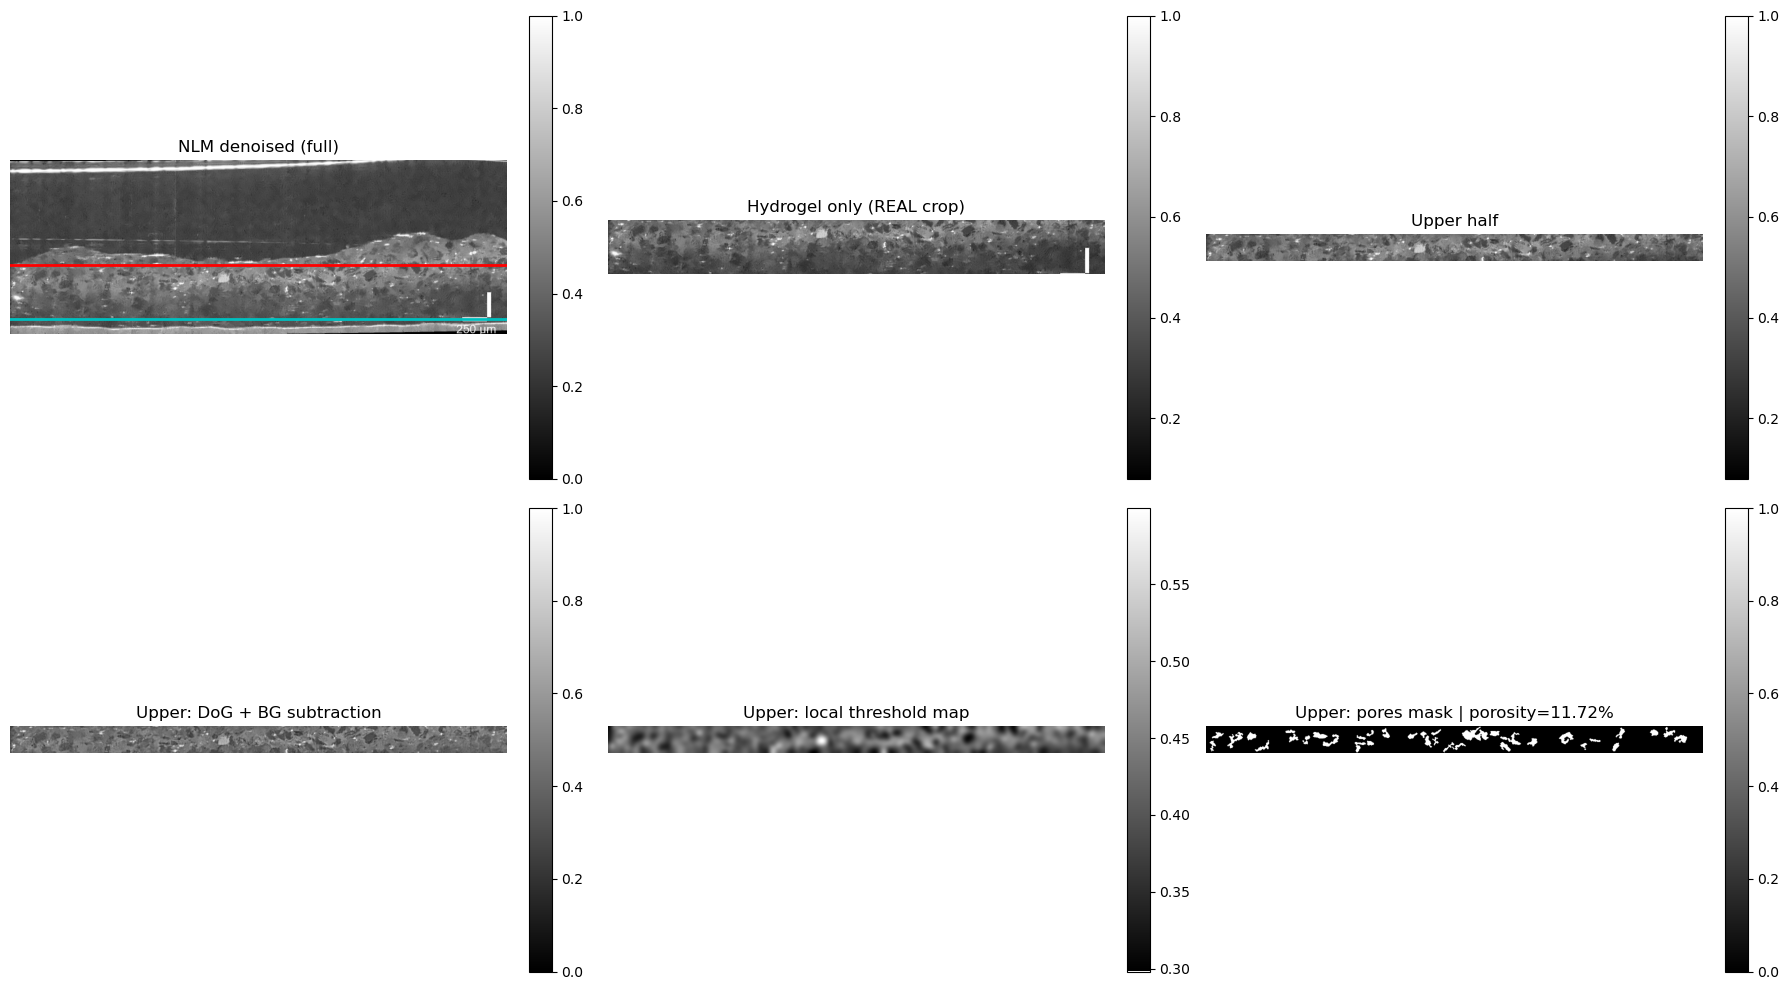

C:\Users\manue\anaconda3\Lib\site-packages\matplotlib\colorbar.py:1233: RuntimeWarning: invalid value encountered in divide
  y = y / (self._boundaries[self._inside][-1] -


IndexError: index 1 is out of bounds for axis 0 with size 1

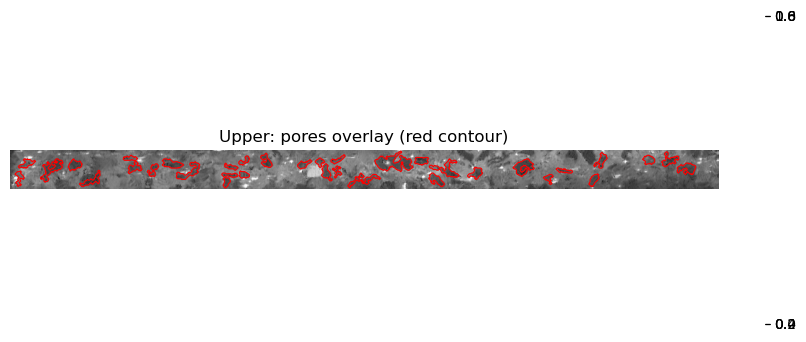

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import tifffile as tiff
from skimage.restoration import denoise_nl_means, estimate_sigma
from scipy.ndimage import gaussian_filter, median_filter, distance_transform_edt
from skimage.filters import sobel, difference_of_gaussians, threshold_local
from skimage.morphology import (
    disk, binary_opening, binary_closing,
    remove_small_objects, remove_small_holes, binary_dilation
)
from skimage.segmentation import clear_border, watershed
from skimage.measure import label


# =========================
# A) SETTINGS (INPUT)
# =========================
IN_FOLDER = Path(r"C:\Users\manue\Desktop\Master_BMED\CMC R4 swelling tiff\CMC R4 swelling tiff")
PATTERN = "251030_CMCH_swelling_PARAFFIN_Sample1_*_Mode2D*.tif*"
# Or set a single file:
# IMAGE_PATH = r"...\251030_...tiff"

# =========================
# B) SETTINGS (NLM + CROP)
# =========================
NLM_H_FACTOR = 1.0

TOP_ZMIN_FRAC = 0.10
TOP_ZMAX_FRAC = 0.70
BOT_ZMIN_FRAC = 0.60
BOT_ZMAX_FRAC = 0.98

SIGMA_SMOOTH = 1.2
MEDIAN_K = 51
MAX_JUMP = 10

TOP_MARGIN = 2
BOT_MARGIN = 6

TOP_PCT = 95   # increase -> cut more background
BOT_PCT = 5    # increase -> cut more bottom support

SPLIT_RATIO = 0.5


# =========================
# C) SETTINGS (PAPER PIPELINE - UPPER)
# =========================
SIGMA_GAUSS = 0.7
DOG_SIGMA1 = 0.7
DOG_SIGMA2 = 2.0

USE_BG_SUB = True
BG_SIGMA = 20

BLOCK_SIZE = 33   # odd
OFFSET = 0.02     # bigger -> fewer pores

SE_RADIUS = 1
MIN_PORE_AREA_PX = 80
FILL_HOLES_AREA_PX = 80

USE_WATERSHED = True
DT_FG_RATIO = 0.25
DT_DILATE_ITERS = 2


# =========================
# Helpers
# =========================
def to_gray_float(img):
    if img.ndim == 2:
        return img.astype(np.float32)
    if img.ndim == 3 and img.shape[2] in (3,4):
        rgb = img[..., :3].astype(np.float32)
        return 0.299*rgb[...,0] + 0.587*rgb[...,1] + 0.114*rgb[...,2]
    raise ValueError(img.shape)

def normalize_percentile01(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, (p_low, p_high))
    x = np.clip(img, lo, hi)
    return ((x - lo) / (hi - lo + 1e-8)).astype(np.float32)

def nlm_denoise(img01, h_factor=1.0):
    sigma = float(np.mean(estimate_sigma(img01, channel_axis=None)))
    out = denoise_nl_means(
        img01, h=h_factor*sigma,
        fast_mode=True, patch_size=5, patch_distance=6,
        channel_axis=None
    )
    return out.astype(np.float32)

def detect_line_grad(img01, zmin_frac, zmax_frac, sigma=1.2):
    H, W = img01.shape
    z0 = int(H*zmin_frac); z1 = int(H*zmax_frac)
    band = img01[z0:z1, :]
    band_s = gaussian_filter(band, sigma=(sigma, sigma))
    g = np.abs(np.gradient(band_s, axis=0))
    z_rel = np.argmax(g, axis=0)
    return z0 + z_rel

def clean_line(z_line, med_k=51, max_jump=10):
    if med_k % 2 == 0: med_k += 1
    z = median_filter(z_line.astype(np.int32), size=med_k)
    z2 = z.copy()
    for x in range(1, len(z2)):
        if abs(z2[x] - z2[x-1]) > max_jump:
            z2[x] = z2[x-1]
    z2 = median_filter(z2.astype(np.int32), size=med_k)
    return z2.astype(int)

def imshow_cbar(ax, img, title, cmap="gray"):
    im = ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im

def paper_upper_pipeline(img01):
    img01 = img01.astype(np.float32)
    roi_mask = img01 > 0

    # gaussian
    g_img = gaussian_filter(img01, sigma=SIGMA_GAUSS).astype(np.float32)

    # DoG (paper-like)
    dog = difference_of_gaussians(g_img, low_sigma=DOG_SIGMA1, high_sigma=DOG_SIGMA2).astype(np.float32)
    enh = img01 + dog
    enh = enh - enh.min()
    enh = enh / (enh.max() + 1e-8)

    # background subtraction (gradient help)
    if USE_BG_SUB:
        bg = gaussian_filter(enh, sigma=BG_SIGMA)
        enh_bp = enh - bg
        enh_bp = enh_bp - enh_bp.min()
        enh_bp = enh_bp / (enh_bp.max() + 1e-8)
    else:
        enh_bp = enh

    # adaptive threshold
    thr_map = threshold_local(enh_bp, block_size=BLOCK_SIZE, method="gaussian", offset=OFFSET)
    pores_bin = (enh_bp < thr_map) & roi_mask  # pores dark

    # morphology
    se = disk(SE_RADIUS)
    pores = binary_opening(pores_bin, se)
    pores = binary_closing(pores, se)

    pores = remove_small_objects(pores, min_size=MIN_PORE_AREA_PX)
    pores = remove_small_holes(pores, area_threshold=FILL_HOLES_AREA_PX)
    pores = clear_border(pores)

    # watershed
    if USE_WATERSHED:
        dt = distance_transform_edt(pores)
        sure_fg = dt > (DT_FG_RATIO * dt.max())

        sure_bg = pores.copy()
        for _ in range(DT_DILATE_ITERS):
            sure_bg = binary_dilation(sure_bg, se)

        unknown = sure_bg & (~sure_fg)
        markers = label(sure_fg).astype(np.int32)
        markers[unknown] = 0

        labels_ws = watershed(-dt, markers, mask=pores)
    else:
        labels_ws = label(pores)

    # porosity
    area_pores = int(np.sum(pores))
    area_roi = int(np.sum(roi_mask))
    porosity = 100.0 * area_pores / (area_roi + 1e-8)

    return enh_bp, thr_map, pores, labels_ws, porosity


# =========================
# RUN (pick a file)
# =========================
files = sorted(IN_FOLDER.glob(PATTERN))
if len(files) == 0:
    raise FileNotFoundError(f"No files found with pattern: {PATTERN}")

f = files[5]
print("Using:", f.name)

raw = tiff.imread(f)
x01 = normalize_percentile01(to_gray_float(raw))
x_nlm = nlm_denoise(x01, h_factor=NLM_H_FACTOR)

H, W = x_nlm.shape

# detect top/bottom lines
z_top_curve = clean_line(detect_line_grad(x_nlm, TOP_ZMIN_FRAC, TOP_ZMAX_FRAC, SIGMA_SMOOTH), MEDIAN_K, MAX_JUMP)
z_bot_curve = clean_line(detect_line_grad(x_nlm, BOT_ZMIN_FRAC, BOT_ZMAX_FRAC, SIGMA_SMOOTH), MEDIAN_K, MAX_JUMP)

# robust straight cuts (percentiles)
z_top = int(np.percentile(z_top_curve, TOP_PCT)) + TOP_MARGIN
z_bot = int(np.percentile(z_bot_curve, BOT_PCT)) - BOT_MARGIN

z_top = np.clip(z_top, 0, H-2)
z_bot = np.clip(z_bot, z_top+50, H-1)

x_hydrogel = x_nlm[z_top:z_bot, :]
thickness = x_hydrogel.shape[0]
z_split = int(thickness * SPLIT_RATIO)

x_upper = x_hydrogel[:z_split, :]
print("Hydrogel thickness px:", thickness, "| Upper px:", x_upper.shape[0])

# apply paper pipeline on upper
enh_bp, thr_map, pores_mask, labels_ws, porosity = paper_upper_pipeline(x_upper)
print(f"Upper porosity (2D) = {porosity:.2f}% | pores count = {labels_ws.max()}")

# =========================
# DISPLAY (colorbars everywhere)
# =========================
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

imshow_cbar(ax[0,0], x_nlm, "NLM denoised (full)", cmap="gray")
ax[0,0].axhline(z_top, color="r", linewidth=2)
ax[0,0].axhline(z_bot, color="c", linewidth=2)

imshow_cbar(ax[0,1], x_hydrogel, "Hydrogel only (REAL crop)", cmap="gray")

imshow_cbar(ax[0,2], x_upper, "Upper half", cmap="gray")

imshow_cbar(ax[1,0], enh_bp, "Upper: DoG + BG subtraction", cmap="gray")

imshow_cbar(ax[1,1], thr_map, "Upper: local threshold map", cmap="gray")

imshow_cbar(ax[1,2], pores_mask.astype(float), f"Upper: pores mask | porosity={porosity:.2f}%", cmap="gray")

plt.tight_layout()
plt.show()

# overlay
plt.figure(figsize=(10,4))
plt.imshow(x_upper, cmap="gray")
plt.contour(pores_mask, colors="r", linewidths=0.8)
plt.title("Upper: pores overlay (red contour)")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

Using: 251030_CMCH_swelling_PARAFFIN_Sample1_0006_Mode2D 7h59.tiff
Hydrogel thickness: 109 px | Upper height: 54 px
Upper: porosity=11.72% | pores=71


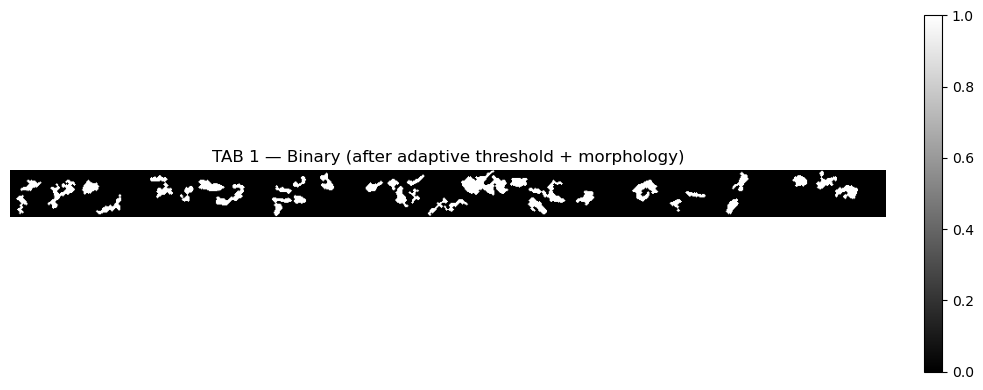

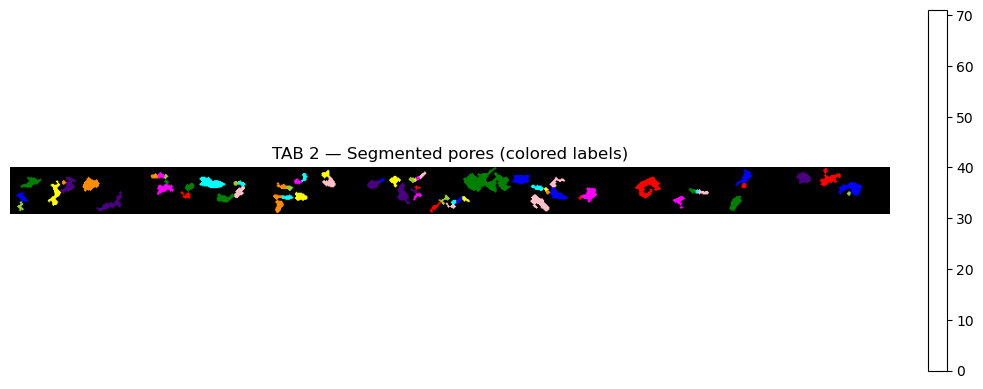

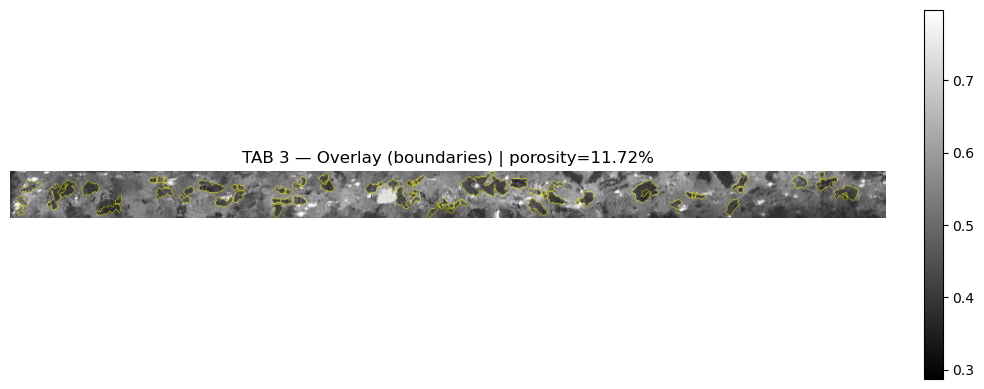

In [10]:
# ============================================================
# EXACT "3 tabs" visualization (Binary / Colored / Overlay)
# BUT using your CUT upper piece (after NLM + straight crop + split)
# - Tab 1: Binary (after adaptive threshold + morphology)
# - Tab 2: Colored segmentation (label2rgb)
# - Tab 3: Overlay (boundaries on grayscale)
# WITH colorbars in EVERY figure.
# ============================================================

from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

from skimage.restoration import denoise_nl_means, estimate_sigma
from scipy.ndimage import gaussian_filter, median_filter, distance_transform_edt

from skimage import filters
from skimage.filters import difference_of_gaussians, threshold_local
from skimage.morphology import (
    disk, binary_opening, binary_closing,
    remove_small_objects, remove_small_holes, binary_dilation
)
from skimage.segmentation import clear_border, watershed, mark_boundaries
from skimage.measure import label
from skimage.color import label2rgb


# =========================
# A) INPUT (pick 1 file)
# =========================
IN_FOLDER = Path(r"C:\Users\manue\Desktop\Master_BMED\CMC R4 swelling tiff\CMC R4 swelling tiff")
PATTERN = "251030_CMCH_swelling_PARAFFIN_Sample1_*_Mode2D*.tif*"
files = sorted(IN_FOLDER.glob(PATTERN))
if not files:
    raise FileNotFoundError(f"No files found with pattern: {PATTERN}")
f = files[5]
print("Using:", f.name)

# =========================
# B) NLM + STRAIGHT CROP + SPLIT (UPPER)
# =========================
NLM_H_FACTOR = 1.0

TOP_ZMIN_FRAC = 0.10
TOP_ZMAX_FRAC = 0.70
BOT_ZMIN_FRAC = 0.60
BOT_ZMAX_FRAC = 0.98

SIGMA_SMOOTH = 1.2
MEDIAN_K = 51
MAX_JUMP = 10

TOP_MARGIN = 2
BOT_MARGIN = 6
TOP_PCT = 95   # higher -> cuts more top background
BOT_PCT = 5    # higher -> cuts more bottom support

SPLIT_RATIO = 0.5  # upper half depth

# ---------- helpers ----------
def to_gray_float(img):
    if img.ndim == 2:
        return img.astype(np.float32)
    if img.ndim == 3 and img.shape[2] in (3,4):
        rgb = img[..., :3].astype(np.float32)
        return 0.299*rgb[...,0] + 0.587*rgb[...,1] + 0.114*rgb[...,2]
    raise ValueError(img.shape)

def normalize_percentile01(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, (p_low, p_high))
    x = np.clip(img, lo, hi)
    return ((x-lo)/(hi-lo+1e-8)).astype(np.float32)

def nlm_denoise(img01, h_factor=1.0):
    sigma = float(np.mean(estimate_sigma(img01, channel_axis=None)))
    out = denoise_nl_means(
        img01, h=h_factor*sigma,
        fast_mode=True, patch_size=5, patch_distance=6,
        channel_axis=None
    )
    return out.astype(np.float32)

def detect_line_grad(img01, zmin_frac, zmax_frac, sigma=1.2):
    H, W = img01.shape
    z0 = int(H*zmin_frac); z1 = int(H*zmax_frac)
    band = img01[z0:z1, :]
    band_s = gaussian_filter(band, sigma=(sigma, sigma))
    g = np.abs(np.gradient(band_s, axis=0))
    z_rel = np.argmax(g, axis=0)
    return z0 + z_rel

def clean_line(z_line, med_k=51, max_jump=10):
    if med_k % 2 == 0: med_k += 1
    z = median_filter(z_line.astype(np.int32), size=med_k)
    z2 = z.copy()
    for x in range(1, len(z2)):
        if abs(z2[x] - z2[x-1]) > max_jump:
            z2[x] = z2[x-1]
    z2 = median_filter(z2.astype(np.int32), size=med_k)
    return z2.astype(int)

def imshow_cbar(ax, img, title, cmap="gray"):
    im = ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im

# ---------- load + NLM ----------
raw = tiff.imread(f)
x01 = normalize_percentile01(to_gray_float(raw), 1, 99)
x_nlm = nlm_denoise(x01, h_factor=NLM_H_FACTOR)

H, W = x_nlm.shape

# detect top/bottom curves
z_top_curve = clean_line(detect_line_grad(x_nlm, TOP_ZMIN_FRAC, TOP_ZMAX_FRAC, SIGMA_SMOOTH), MEDIAN_K, MAX_JUMP)
z_bot_curve = clean_line(detect_line_grad(x_nlm, BOT_ZMIN_FRAC, BOT_ZMAX_FRAC, SIGMA_SMOOTH), MEDIAN_K, MAX_JUMP)

# straight robust lines (percentiles)
z_top = int(np.percentile(z_top_curve, TOP_PCT)) + TOP_MARGIN
z_bot = int(np.percentile(z_bot_curve, BOT_PCT)) - BOT_MARGIN

z_top = int(np.clip(z_top, 0, H-2))
z_bot = int(np.clip(z_bot, z_top+50, H-1))

# REAL crop (no black background)
x_hydrogel = x_nlm[z_top:z_bot, :]
thickness = x_hydrogel.shape[0]
z_split = int(thickness * SPLIT_RATIO)

x_upper = x_hydrogel[:z_split, :]
print("Hydrogel thickness:", thickness, "px | Upper height:", x_upper.shape[0], "px")

# =========================
# C) "ARTICLE" PIPELINE ON UPPER (same style outputs)
# =========================
SIGMA_GAUSS = 0.7
DOG_SIGMA1 = 0.7
DOG_SIGMA2 = 2.0

USE_BG_SUB = True
BG_SIGMA = 20

BLOCK_SIZE = 33  # odd
OFFSET = 0.02

SE_RADIUS = 1
MIN_PORE_AREA_PX = 80
FILL_HOLES_AREA_PX = 80

USE_WATERSHED = True
DT_FG_RATIO = 0.25
DT_DILATE_ITERS = 2

roi_mask = x_upper > 0

# Gaussian
g_img = gaussian_filter(x_upper, sigma=SIGMA_GAUSS).astype(np.float32)

# DoG enhance (paper-like)
dog = difference_of_gaussians(g_img, low_sigma=DOG_SIGMA1, high_sigma=DOG_SIGMA2).astype(np.float32)
enh = x_upper + dog
enh = enh - enh.min()
enh = enh / (enh.max() + 1e-8)

# BG subtraction (helps gradient)
if USE_BG_SUB:
    bg = gaussian_filter(enh, sigma=BG_SIGMA)
    enh_bp = enh - bg
    enh_bp = enh_bp - enh_bp.min()
    enh_bp = enh_bp / (enh_bp.max() + 1e-8)
else:
    enh_bp = enh

# adaptive threshold (pores dark)
thr_map = threshold_local(enh_bp, block_size=BLOCK_SIZE, method="gaussian", offset=OFFSET)
thG = (enh_bp < thr_map) & roi_mask  # binary pores

# morphology (paper-like cleanup)
se = disk(SE_RADIUS)
Morph = binary_opening(thG, se)
Morph = binary_closing(Morph, se)
Morph = remove_small_objects(Morph, min_size=MIN_PORE_AREA_PX)
Morph = remove_small_holes(Morph, area_threshold=FILL_HOLES_AREA_PX)
clearimg = clear_border(Morph)

# watershed (separate touching pores)
if USE_WATERSHED:
    dt = distance_transform_edt(clearimg)
    sure_fg = dt > (DT_FG_RATIO * dt.max())

    sure_bg = clearimg.copy()
    for _ in range(DT_DILATE_ITERS):
        sure_bg = binary_dilation(sure_bg, se)

    unknown = sure_bg & (~sure_fg)

    markers = label(sure_fg).astype(np.int32)
    markers[unknown] = 0

    labels_ws = watershed(-dt, markers, mask=clearimg)
else:
    labels_ws = label(clearimg)

pores_binary = labels_ws > 0
porosity = 100.0 * pores_binary.sum() / (roi_mask.sum() + 1e-8)
n_pores = int(labels_ws.max())
print(f"Upper: porosity={porosity:.2f}% | pores={n_pores}")

# =========================
# D) SHOW RESULTS EXACTLY AS 3 "TABS"
# =========================
# --- TAB 1: Binary (threshold + morphology) ---
plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(clearimg.astype(float), cmap="gray")
ax.set_title("TAB 1 — Binary (after adaptive threshold + morphology)")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# --- TAB 2: Colored segmentation (label2rgb) ---
# label2rgb returns RGB float image; we still add a colorbar using the label image.
seg_rgb = label2rgb(labels_ws, image=None, bg_label=0)  # colored regions
plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(seg_rgb)
ax.set_title("TAB 2 — Segmented pores (colored labels)")
ax.axis("off")
# colorbar based on label IDs
mappable = ax.imshow(labels_ws.astype(float), cmap="nipy_spectral", alpha=0.0)
plt.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# --- TAB 3: Overlay (boundaries on grayscale) ---
# mark_boundaries draws boundaries; for display we keep grayscale with boundaries visible
vmin, vmax = np.percentile(x_upper[x_upper > 0], (1, 99)) if (x_upper > 0).any() else (0, 1)
overlay = mark_boundaries(
    (np.clip(x_upper, 0, 1)), labels_ws,
    color=(1, 1, 0),  # yellow boundaries (like paper overlay vibe)
    mode="outer"
)
plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(x_upper, cmap="gray", vmin=vmin, vmax=vmax)
ax.imshow(overlay, alpha=0.6)  # boundaries on top
ax.set_title(f"TAB 3 — Overlay (boundaries) | porosity={porosity:.2f}%")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Using: oct_12.5_0017_Mode2D.tiff
Hydrogel thickness: 502 px | Upper height: 251 px
Upper: porosity=65.27% | pores=459


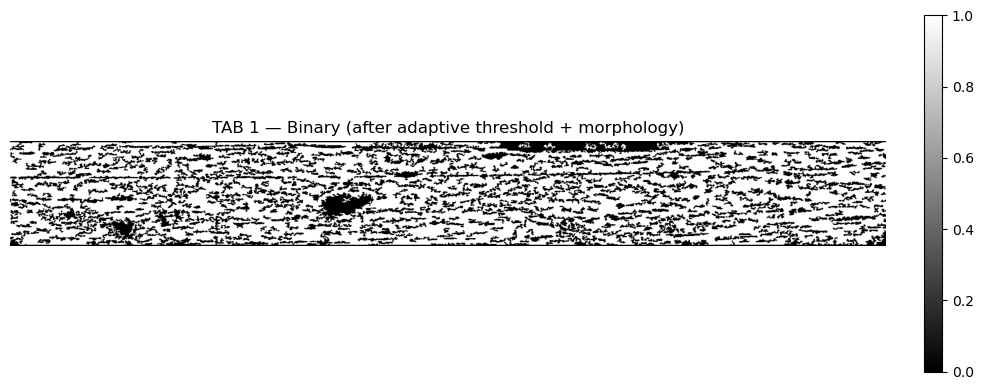

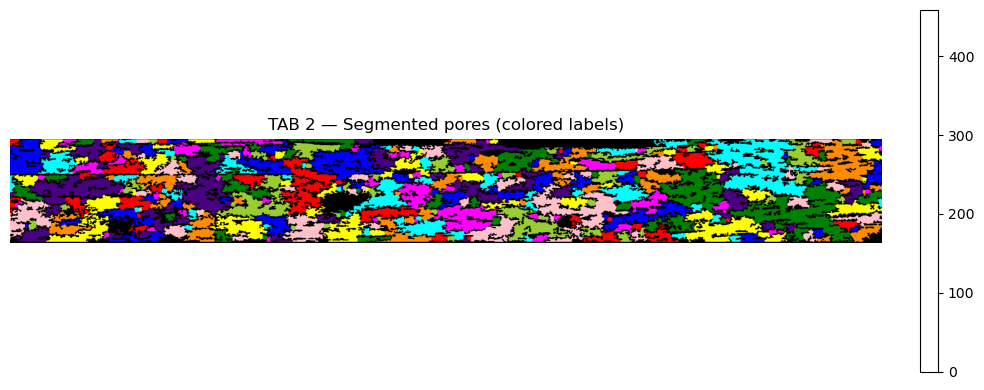

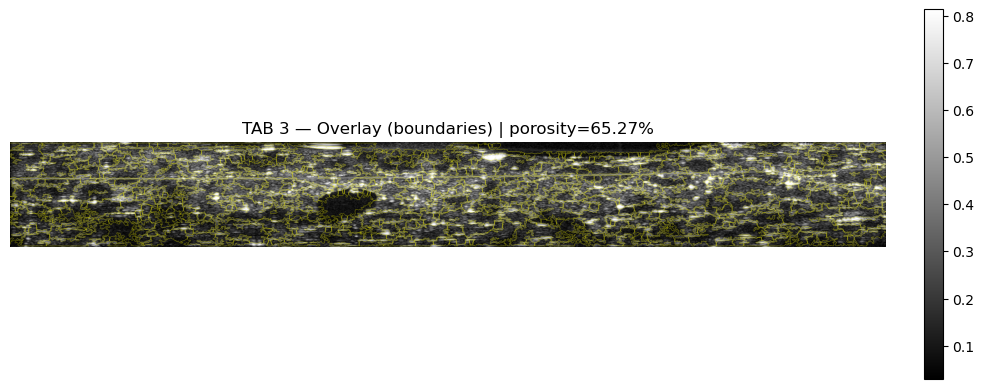

In [12]:
# ============================================================
# EXACT "3 tabs" visualization (Binary / Colored / Overlay)
# BUT using your CUT upper piece (after NLM + straight crop + split)
# - Tab 1: Binary (after adaptive threshold + morphology)
# - Tab 2: Colored segmentation (label2rgb)
# - Tab 3: Overlay (boundaries on grayscale)
# WITH colorbars in EVERY figure.
#
# MODS (to keep pores at margins):
# - REMOVE clear_border (it deletes edge pores)
# - LATERAL reflect padding before threshold + morphology
# - Clean ONLY top/bottom rows (not left/right)
# ============================================================

from pathlib import Path
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

from skimage.restoration import denoise_nl_means, estimate_sigma
from scipy.ndimage import gaussian_filter, median_filter, distance_transform_edt

from skimage import filters
from skimage.filters import difference_of_gaussians, threshold_local
from skimage.morphology import (
    disk, binary_opening, binary_closing,
    remove_small_objects, remove_small_holes, binary_dilation
)
from skimage.segmentation import watershed, mark_boundaries
from skimage.measure import label
from skimage.color import label2rgb


# =========================
# A) INPUT (pick 1 file)
# =========================
#C:\Users\manue\Desktop\Master_BMED\Boite 1\Boite 1"
#IN_FOLDER = Path(r"C:\Users\manue\Desktop\Master_BMED\CMC R4 swelling tiff\CMC R4 swelling tiff")
IN_FOLDER = Path(r"C:\Users\manue\Desktop\Master_BMED\Boite 1\Boite 1")
PATTERN = "oct_*_*_Mode2D.tif*"
#PATTERN = "251030_CMCH_swelling_PARAFFIN_Sample1_*_Mode2D*.tif*"
files = sorted(IN_FOLDER.glob(PATTERN))
if not files:
    raise FileNotFoundError(f"No files found with pattern: {PATTERN}")
f = files[4]
print("Using:", f.name)

# =========================
# B) NLM + STRAIGHT CROP + SPLIT (UPPER)
# =========================
NLM_H_FACTOR = 1.0

TOP_ZMIN_FRAC = 0.10
TOP_ZMAX_FRAC = 0.70
BOT_ZMIN_FRAC = 0.60
BOT_ZMAX_FRAC = 0.98

SIGMA_SMOOTH = 1.2
MEDIAN_K = 51
MAX_JUMP = 10

TOP_MARGIN = 2
BOT_MARGIN = 6
TOP_PCT = 95   # higher -> cuts more top background
BOT_PCT = 5    # higher -> cuts more bottom support

SPLIT_RATIO = 0.5  # upper half depth

# ---------- helpers ----------
def to_gray_float(img):
    if img.ndim == 2:
        return img.astype(np.float32)
    if img.ndim == 3 and img.shape[2] in (3,4):
        rgb = img[..., :3].astype(np.float32)
        return 0.299*rgb[...,0] + 0.587*rgb[...,1] + 0.114*rgb[...,2]
    raise ValueError(img.shape)

def normalize_percentile01(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, (p_low, p_high))
    x = np.clip(img, lo, hi)
    return ((x-lo)/(hi-lo+1e-8)).astype(np.float32)

def nlm_denoise(img01, h_factor=1.0):
    sigma = float(np.mean(estimate_sigma(img01, channel_axis=None)))
    out = denoise_nl_means(
        img01, h=h_factor*sigma,
        fast_mode=True, patch_size=5, patch_distance=6,
        channel_axis=None
    )
    return out.astype(np.float32)

def detect_line_grad(img01, zmin_frac, zmax_frac, sigma=1.2):
    H, W = img01.shape
    z0 = int(H*zmin_frac); z1 = int(H*zmax_frac)
    band = img01[z0:z1, :]
    band_s = gaussian_filter(band, sigma=(sigma, sigma))
    g = np.abs(np.gradient(band_s, axis=0))
    z_rel = np.argmax(g, axis=0)
    return z0 + z_rel

def clean_line(z_line, med_k=51, max_jump=10):
    if med_k % 2 == 0: med_k += 1
    z = median_filter(z_line.astype(np.int32), size=med_k)
    z2 = z.copy()
    for x in range(1, len(z2)):
        if abs(z2[x] - z2[x-1]) > max_jump:
            z2[x] = z2[x-1]
    z2 = median_filter(z2.astype(np.int32), size=med_k)
    return z2.astype(int)

# ---------- load + NLM ----------
raw = tiff.imread(f)
x01 = normalize_percentile01(to_gray_float(raw), 1, 99)
x_nlm = nlm_denoise(x01, h_factor=NLM_H_FACTOR)

H, W = x_nlm.shape

# detect top/bottom curves
z_top_curve = clean_line(detect_line_grad(x_nlm, TOP_ZMIN_FRAC, TOP_ZMAX_FRAC, SIGMA_SMOOTH), MEDIAN_K, MAX_JUMP)
z_bot_curve = clean_line(detect_line_grad(x_nlm, BOT_ZMIN_FRAC, BOT_ZMAX_FRAC, SIGMA_SMOOTH), MEDIAN_K, MAX_JUMP)

# straight robust lines (percentiles)
z_top = int(np.percentile(z_top_curve, TOP_PCT)) + TOP_MARGIN
z_bot = int(np.percentile(z_bot_curve, BOT_PCT)) - BOT_MARGIN

z_top = int(np.clip(z_top, 0, H-2))
z_bot = int(np.clip(z_bot, z_top+50, H-1))

# REAL crop (no black background)
x_hydrogel = x_nlm[z_top:z_bot, :]
thickness = x_hydrogel.shape[0]
z_split = int(thickness * SPLIT_RATIO)

x_upper = x_hydrogel[:z_split, :]
print("Hydrogel thickness:", thickness, "px | Upper height:", x_upper.shape[0], "px")

# =========================
# C) "ARTICLE" PIPELINE ON UPPER (same style outputs)
# =========================
SIGMA_GAUSS = 0.7
DOG_SIGMA1 = 0.7
DOG_SIGMA2 = 2.0

USE_BG_SUB = True
BG_SIGMA = 20

BLOCK_SIZE = 33  # odd
OFFSET = 0.02

SE_RADIUS = 1
MIN_PORE_AREA_PX = 80
FILL_HOLES_AREA_PX = 80

USE_WATERSHED = True
DT_FG_RATIO = 0.25
DT_DILATE_ITERS = 2

# NEW: padding to keep edge pores
PAD = 20          # 10–40
TOPBOT_CLEAN = 3  # rows to remove at top/bottom (NOT sides)

roi_mask = x_upper > 0

# Gaussian
g_img = gaussian_filter(x_upper, sigma=SIGMA_GAUSS).astype(np.float32)

# DoG enhance (paper-like)
dog = difference_of_gaussians(g_img, low_sigma=DOG_SIGMA1, high_sigma=DOG_SIGMA2).astype(np.float32)
enh = x_upper + dog
enh = enh - enh.min()
enh = enh / (enh.max() + 1e-8)

# BG subtraction (helps gradient)
if USE_BG_SUB:
    bg = gaussian_filter(enh, sigma=BG_SIGMA)
    enh_bp = enh - bg
    enh_bp = enh_bp - enh_bp.min()
    enh_bp = enh_bp / (enh_bp.max() + 1e-8)
else:
    enh_bp = enh

# -------------------------
# ADAPTIVE THRESH + MORPH (BORDER-SAFE)
# -------------------------
enh_bp_pad = np.pad(enh_bp, ((0,0),(PAD,PAD)), mode="reflect")
roi_pad    = np.pad(roi_mask, ((0,0),(PAD,PAD)), mode="reflect")

thr_map_pad = threshold_local(enh_bp_pad, block_size=BLOCK_SIZE, method="gaussian", offset=OFFSET)
thG_pad = (enh_bp_pad < thr_map_pad) & roi_pad  # pores = dark

se = disk(SE_RADIUS)

# less aggressive, better at edges
Morph_pad = binary_closing(thG_pad, se)  # closing first helps keep border pores
Morph_pad = remove_small_objects(Morph_pad, min_size=MIN_PORE_AREA_PX)
Morph_pad = remove_small_holes(Morph_pad, area_threshold=FILL_HOLES_AREA_PX)

# remove only top/bottom junk (NOT laterals)
Morph_pad[:TOPBOT_CLEAN, :] = False
Morph_pad[-TOPBOT_CLEAN:, :] = False

# unpad
clearimg = Morph_pad[:, PAD:-PAD]

# -------------------------
# WATERSHED (same idea)
# -------------------------
if USE_WATERSHED:
    dt = distance_transform_edt(clearimg)
    sure_fg = dt > (DT_FG_RATIO * dt.max())

    sure_bg = clearimg.copy()
    for _ in range(DT_DILATE_ITERS):
        sure_bg = binary_dilation(sure_bg, se)

    unknown = sure_bg & (~sure_fg)

    markers = label(sure_fg).astype(np.int32)
    markers[unknown] = 0

    labels_ws = watershed(-dt, markers, mask=clearimg)
else:
    labels_ws = label(clearimg)

pores_binary = labels_ws > 0
porosity = 100.0 * pores_binary.sum() / (roi_mask.sum() + 1e-8)
n_pores = int(labels_ws.max())
print(f"Upper: porosity={porosity:.2f}% | pores={n_pores}")

# =========================
# D) SHOW RESULTS EXACTLY AS 3 "TABS"
# =========================
# --- TAB 1: Binary (threshold + morphology) ---
plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(clearimg.astype(float), cmap="gray")
ax.set_title("TAB 1 — Binary (after adaptive threshold + morphology)")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# --- TAB 2: Colored segmentation (label2rgb) ---
seg_rgb = label2rgb(labels_ws, image=None, bg_label=0)
plt.figure(figsize=(10, 4))
ax = plt.gca()
ax.imshow(seg_rgb)
ax.set_title("TAB 2 — Segmented pores (colored labels)")
ax.axis("off")
mappable = ax.imshow(labels_ws.astype(float), cmap="nipy_spectral", alpha=0.0)
plt.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# --- TAB 3: Overlay (boundaries on grayscale) ---
vmin, vmax = np.percentile(x_upper[x_upper > 0], (1, 99)) if (x_upper > 0).any() else (0, 1)
overlay = mark_boundaries(
    np.clip(x_upper, 0, 1),
    labels_ws,
    color=(1, 1, 0),
    mode="outer"
)
plt.figure(figsize=(10, 4))
ax = plt.gca()
im = ax.imshow(x_upper, cmap="gray", vmin=vmin, vmax=vmax)
ax.imshow(overlay, alpha=0.6)
ax.set_title(f"TAB 3 — Overlay (boundaries) | porosity={porosity:.2f}%")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Número de poros detectados: 71
Área media (px): 89.11267605633803
Área mediana (px): 52.0


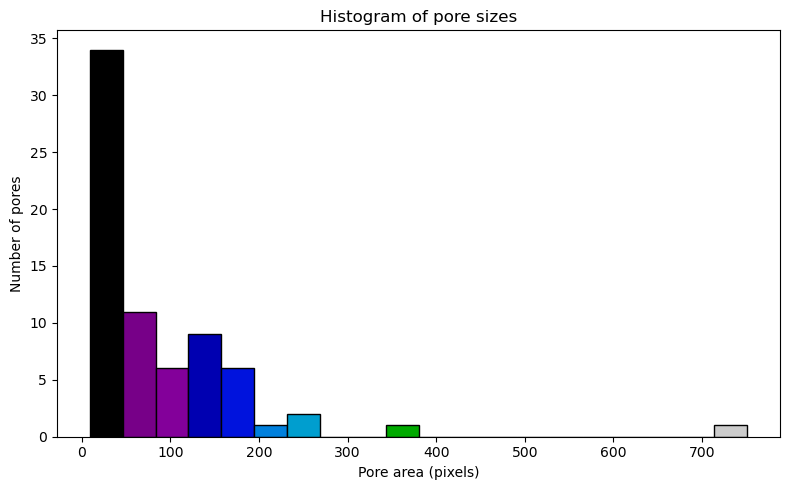

In [4]:
from skimage.measure import regionprops
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# HISTOGRAMA DE TAMAÑO DE POROS (a partir de labels_ws)
# ============================================================

# Obtener propiedades de cada poro
props = regionprops(labels_ws)

# Área de cada poro en píxeles
areas = np.array([p.area for p in props])

print("Número de poros detectados:", len(areas))
print("Área media (px):", np.mean(areas))
print("Área mediana (px):", np.median(areas))

# Número de bins del histograma
bins = 20

# Calcular histograma
counts, bin_edges = np.histogram(areas, bins=bins)

# Colores usando el mismo colormap que el mapa segmentado
cmap = plt.cm.nipy_spectral
colors = cmap(np.linspace(0,1,bins))

# Plot del histograma
plt.figure(figsize=(8,5))

for i in range(bins):
    plt.bar(
        bin_edges[i],
        counts[i],
        width=bin_edges[i+1] - bin_edges[i],
        color=colors[i],
        edgecolor="black",
        align="edge"
    )

plt.xlabel("Pore area (pixels)")
plt.ylabel("Number of pores")
plt.title("Histogram of pore sizes")
plt.tight_layout()
plt.show()

========== PORE ANALYSIS ==========
Number of pore candidates: 71
Porosity (%): 11.72
Mean pore area: 89.11 µm²
Median pore area: 52.00 µm²
Mean equiv. diameter: 9.52 µm
Median equiv. diameter: 8.14 µm

========== BRIGHT ARTIFACT ANALYSIS ==========
Number of bright artifacts: 15
Bright area fraction (%): 0.52


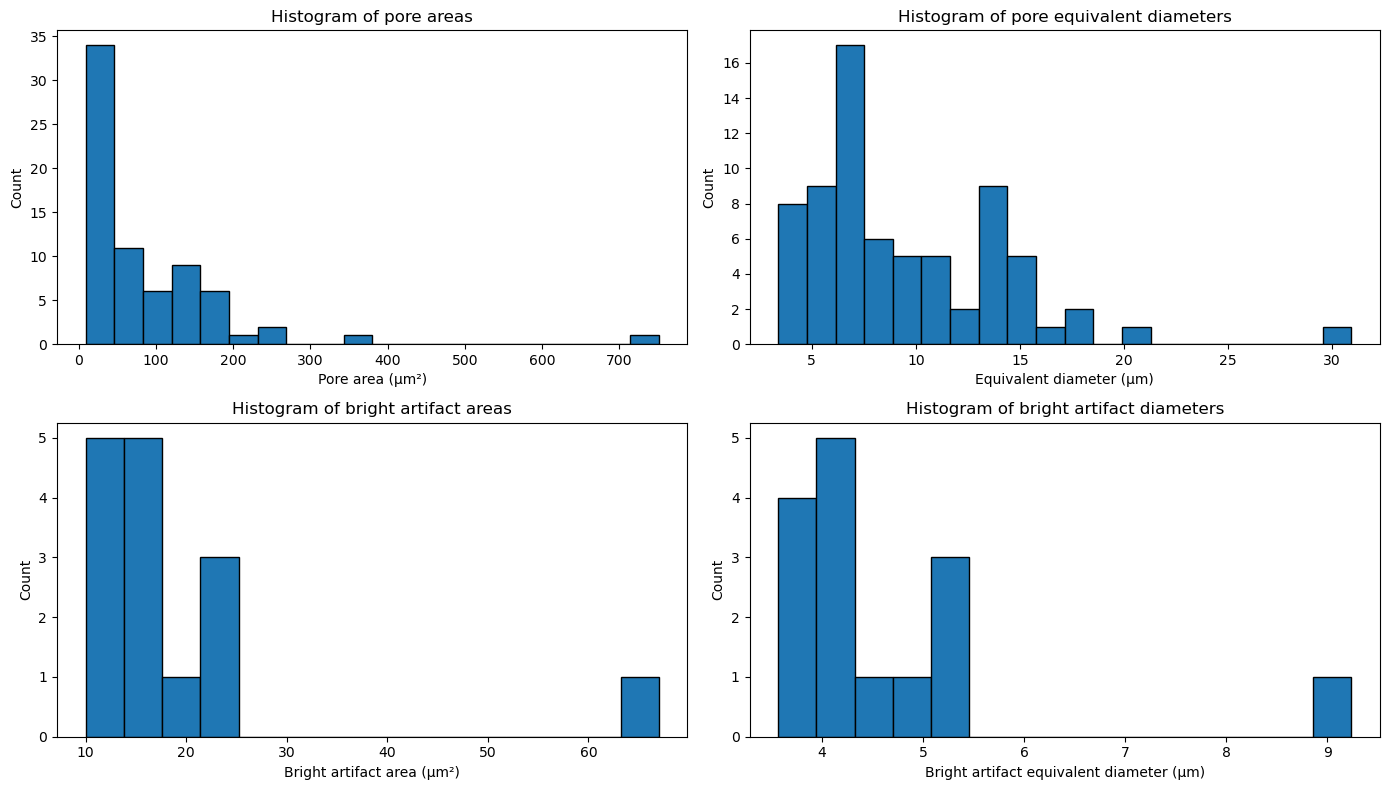

C:\Users\manue\anaconda3\Lib\site-packages\matplotlib\colorbar.py:1233: RuntimeWarning: invalid value encountered in divide
  y = y / (self._boundaries[self._inside][-1] -


IndexError: index 1 is out of bounds for axis 0 with size 1

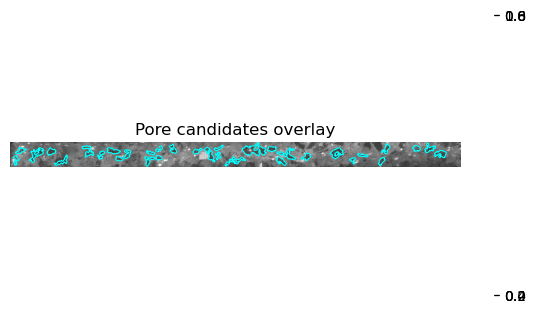

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.measure import regionprops_table, label
from skimage.morphology import remove_small_objects, binary_closing, disk
from scipy.ndimage import binary_fill_holes

# ============================================================
# 1) PORE ANALYSIS
# ============================================================

# If you know the scale, replace this value:
pixel_to_um = 1.0
pixel_area_um2 = pixel_to_um ** 2

# --- region properties for pores ---
props_pores = regionprops_table(
    labels_ws,
    intensity_image=x_upper,
    properties=[
        "label",
        "area",
        "equivalent_diameter",
        "perimeter",
        "eccentricity",
        "solidity",
        "centroid"
    ]
)

df_pores = pd.DataFrame(props_pores)

# convert to physical units if needed
df_pores["area_um2"] = df_pores["area"] * pixel_area_um2
df_pores["equivalent_diameter_um"] = df_pores["equivalent_diameter"] * pixel_to_um
df_pores["perimeter_um"] = df_pores["perimeter"] * pixel_to_um

# --- global pore summary ---
n_pores = len(df_pores)
mean_area = df_pores["area_um2"].mean() if n_pores > 0 else np.nan
median_area = df_pores["area_um2"].median() if n_pores > 0 else np.nan
mean_diam = df_pores["equivalent_diameter_um"].mean() if n_pores > 0 else np.nan
median_diam = df_pores["equivalent_diameter_um"].median() if n_pores > 0 else np.nan

porosity = 100.0 * pores_binary.sum() / (roi_mask.sum() + 1e-8)

print("========== PORE ANALYSIS ==========")
print(f"Number of pore candidates: {n_pores}")
print(f"Porosity (%): {porosity:.2f}")
print(f"Mean pore area: {mean_area:.2f} µm²")
print(f"Median pore area: {median_area:.2f} µm²")
print(f"Mean equiv. diameter: {mean_diam:.2f} µm")
print(f"Median equiv. diameter: {median_diam:.2f} µm")

# ============================================================
# 2) BRIGHT ARTIFACT ANALYSIS
# ============================================================

# detect hyper-reflective regions
BRIGHT_PCT = 99.3          # try 99.0–99.8
BRIGHT_MIN_AREA = 10       # remove tiny pixels
BRIGHT_CLOSE_RADIUS = 1

bright_thr = np.percentile(x_upper[roi_mask], BRIGHT_PCT)
bright_mask = (x_upper >= bright_thr) & roi_mask

# cleanup
bright_mask = binary_closing(bright_mask, disk(BRIGHT_CLOSE_RADIUS))
bright_mask = binary_fill_holes(bright_mask)
bright_mask = remove_small_objects(bright_mask, min_size=BRIGHT_MIN_AREA)

bright_labels = label(bright_mask)

props_bright = regionprops_table(
    bright_labels,
    intensity_image=x_upper,
    properties=[
        "label",
        "area",
        "equivalent_diameter",
        "perimeter",
        "eccentricity",
        "solidity",
        "centroid",
        "mean_intensity",
        "max_intensity"
    ]
)

df_bright = pd.DataFrame(props_bright)

df_bright["area_um2"] = df_bright["area"] * pixel_area_um2
df_bright["equivalent_diameter_um"] = df_bright["equivalent_diameter"] * pixel_to_um

n_bright = len(df_bright)
bright_fraction = 100.0 * bright_mask.sum() / (roi_mask.sum() + 1e-8)

print("\n========== BRIGHT ARTIFACT ANALYSIS ==========")
print(f"Number of bright artifacts: {n_bright}")
print(f"Bright area fraction (%): {bright_fraction:.2f}")

# ============================================================
# 3) HISTOGRAMS
# ============================================================

plt.figure(figsize=(14, 8))

# --- pore area histogram ---
plt.subplot(2,2,1)
if n_pores > 0:
    plt.hist(df_pores["area_um2"], bins=20, edgecolor="black")
plt.xlabel("Pore area (µm²)")
plt.ylabel("Count")
plt.title("Histogram of pore areas")

# --- pore equivalent diameter histogram ---
plt.subplot(2,2,2)
if n_pores > 0:
    plt.hist(df_pores["equivalent_diameter_um"], bins=20, edgecolor="black")
plt.xlabel("Equivalent diameter (µm)")
plt.ylabel("Count")
plt.title("Histogram of pore equivalent diameters")

# --- bright artifact area histogram ---
plt.subplot(2,2,3)
if n_bright > 0:
    plt.hist(df_bright["area_um2"], bins=15, edgecolor="black")
plt.xlabel("Bright artifact area (µm²)")
plt.ylabel("Count")
plt.title("Histogram of bright artifact areas")

# --- bright artifact diameter histogram ---
plt.subplot(2,2,4)
if n_bright > 0:
    plt.hist(df_bright["equivalent_diameter_um"], bins=15, edgecolor="black")
plt.xlabel("Bright artifact equivalent diameter (µm)")
plt.ylabel("Count")
plt.title("Histogram of bright artifact diameters")

plt.tight_layout()
plt.show()

# ============================================================
# 4) VISUAL MAPS
# ============================================================

plt.figure(figsize=(14, 8))

# pores overlay
plt.subplot(2,2,1)
plt.imshow(x_upper, cmap="gray")
plt.contour(pores_binary, colors="cyan", linewidths=0.8)
plt.title("Pore candidates overlay")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# bright artifact overlay
plt.subplot(2,2,2)
plt.imshow(x_upper, cmap="gray")
plt.contour(bright_mask, colors="red", linewidths=0.8)
plt.title("Bright artifacts overlay")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# labeled pores
plt.subplot(2,2,3)
plt.imshow(labels_ws, cmap="nipy_spectral")
plt.title("Labeled pore candidates")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# labeled bright artifacts
plt.subplot(2,2,4)
plt.imshow(bright_labels, cmap="hot")
plt.title("Labeled bright artifacts")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ============================================================
# 5) OPTIONAL: SAVE TABLES
# ============================================================

save_csv = True
if save_csv:
    df_pores.to_csv("pore_candidates_metrics.csv", index=False)
    df_bright.to_csv("bright_artifacts_metrics.csv", index=False)
    print("\nSaved:")
    print("- pore_candidates_metrics.csv")
    print("- bright_artifacts_metrics.csv")


========== GLOBAL CV OF PORE SIZE ==========
CV of pore area (%): 118.06
CV of equivalent diameter (%): 50.43
CV of perimeter (%): 79.85

========== SPATIAL CV ==========
CV of local porosity (%): 110.60
CV of local pore count (%): 135.91

========== DEPTH-WISE CV ==========
CV of porosity across depth bands (%): 55.14

========== INTERPRETATION (HEURISTIC) ==========
Global size distribution (diameter): high variability / heterogeneous
Spatial distribution (local porosity): high variability / heterogeneous
Depth dependence: high variability / heterogeneous


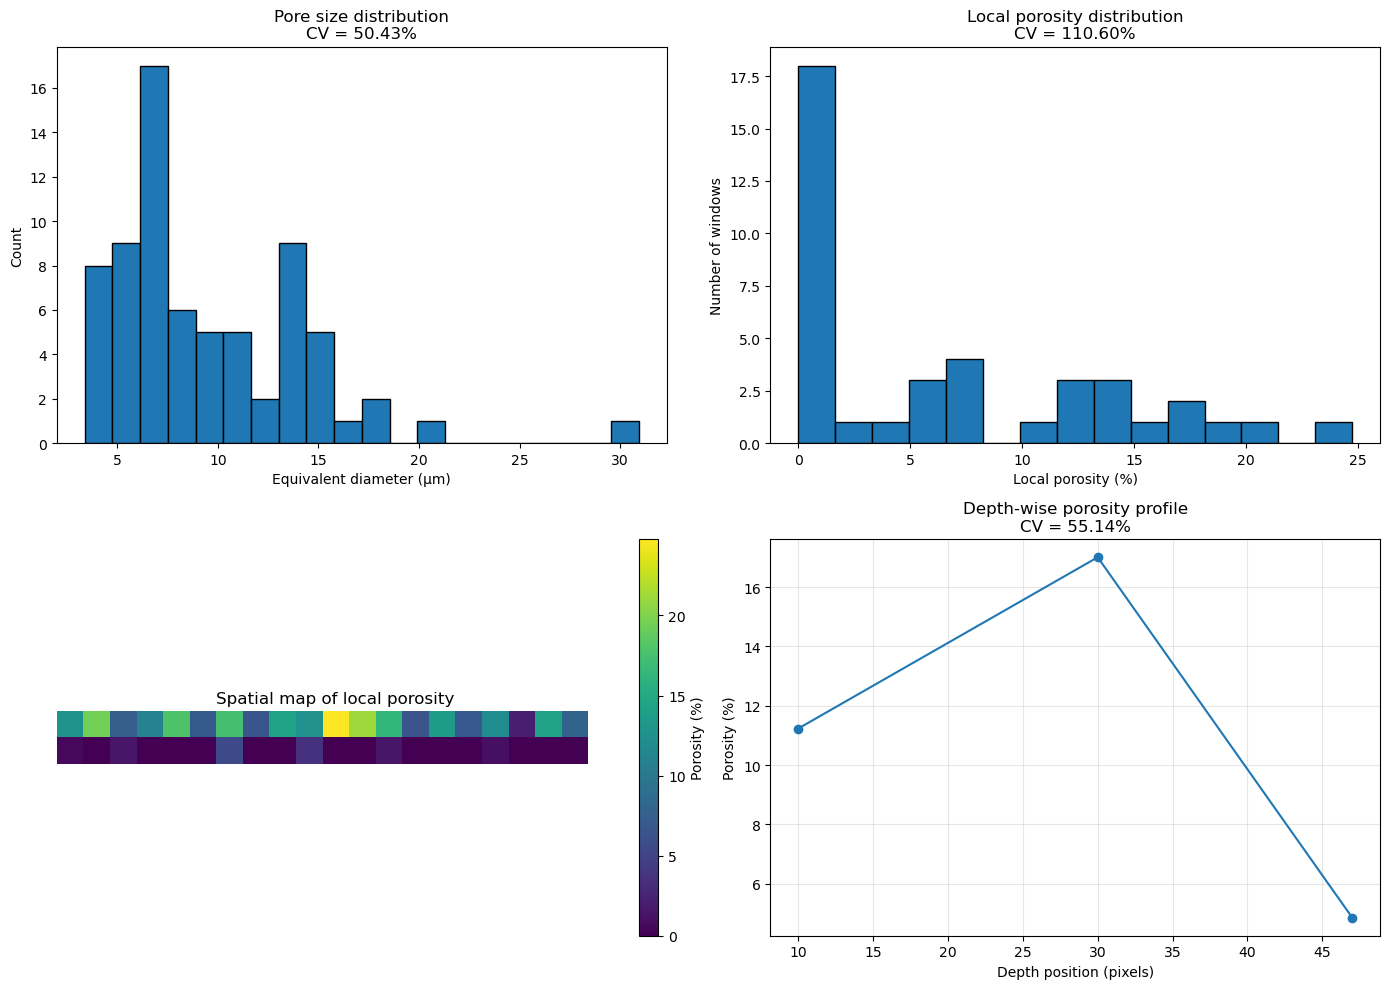


Saved: cv_summary_metrics.csv


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 6) COEFFICIENT OF VARIATION (CV) ANALYSIS
#    - Global CV of pore size
#    - Spatial CV of local porosity
# ============================================================

def safe_cv(x):
    """
    Coefficient of variation in %.
    Returns NaN if mean is zero or data are insufficient.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan
    mean_x = np.mean(x)
    std_x = np.std(x, ddof=1)   # sample std
    if np.isclose(mean_x, 0):
        return np.nan
    return 100.0 * std_x / mean_x


# ------------------------------------------------------------
# A) GLOBAL CV OF SIZE-RELATED METRICS
# ------------------------------------------------------------
cv_area = safe_cv(df_pores["area_um2"]) if len(df_pores) > 0 else np.nan
cv_diam = safe_cv(df_pores["equivalent_diameter_um"]) if len(df_pores) > 0 else np.nan
cv_perim = safe_cv(df_pores["perimeter_um"]) if len(df_pores) > 0 else np.nan

print("\n========== GLOBAL CV OF PORE SIZE ==========")
print(f"CV of pore area (%): {cv_area:.2f}")
print(f"CV of equivalent diameter (%): {cv_diam:.2f}")
print(f"CV of perimeter (%): {cv_perim:.2f}")


# ------------------------------------------------------------
# B) SPATIAL CV OF LOCAL POROSITY
#    Divide ROI into windows and compute local porosity
# ------------------------------------------------------------
WINDOW_SIZE = 50   # pixels, adjust depending on image size
MIN_ROI_FRACTION = 0.30  # keep windows with at least 30% ROI coverage

h, w = pores_binary.shape

local_porosity_map = np.full((h // WINDOW_SIZE + 1, w // WINDOW_SIZE + 1), np.nan)
local_count_map = np.full((h // WINDOW_SIZE + 1, w // WINDOW_SIZE + 1), np.nan)

local_porosity_values = []
local_count_values = []

for i, y0 in enumerate(range(0, h, WINDOW_SIZE)):
    for j, x0 in enumerate(range(0, w, WINDOW_SIZE)):
        y1 = min(y0 + WINDOW_SIZE, h)
        x1 = min(x0 + WINDOW_SIZE, w)

        roi_block = roi_mask[y0:y1, x0:x1]
        pore_block = pores_binary[y0:y1, x0:x1]

        roi_pixels = roi_block.sum()
        total_pixels = roi_block.size

        # skip blocks with too little hydrogel content
        if roi_pixels < MIN_ROI_FRACTION * total_pixels:
            continue

        # local porosity inside hydrogel only
        local_porosity = 100.0 * pore_block[roi_block].sum() / (roi_pixels + 1e-8)

        # number of labeled pore objects whose centroids fall inside the block
        if len(df_pores) > 0:
            in_block = (
                (df_pores["centroid-0"] >= y0) & (df_pores["centroid-0"] < y1) &
                (df_pores["centroid-1"] >= x0) & (df_pores["centroid-1"] < x1)
            )
            local_count = in_block.sum()
        else:
            local_count = 0

        local_porosity_map[i, j] = local_porosity
        local_count_map[i, j] = local_count

        local_porosity_values.append(local_porosity)
        local_count_values.append(local_count)

local_porosity_values = np.array(local_porosity_values, dtype=float)
local_count_values = np.array(local_count_values, dtype=float)

cv_local_porosity = safe_cv(local_porosity_values)
cv_local_count = safe_cv(local_count_values)

print("\n========== SPATIAL CV ==========")
print(f"CV of local porosity (%): {cv_local_porosity:.2f}")
print(f"CV of local pore count (%): {cv_local_count:.2f}")


# ------------------------------------------------------------
# C) OPTIONAL: RADIAL / DEPTH-WISE CV
#    Useful if OCT still has residual depth effects
# ------------------------------------------------------------
# Example: porosity per row band
BAND_HEIGHT = 20  # pixels

band_porosity = []
band_positions = []

for y0 in range(0, h, BAND_HEIGHT):
    y1 = min(y0 + BAND_HEIGHT, h)
    roi_band = roi_mask[y0:y1, :]
    pore_band = pores_binary[y0:y1, :]

    roi_pixels = roi_band.sum()
    if roi_pixels < 10:
        continue

    p_band = 100.0 * pore_band[roi_band].sum() / (roi_pixels + 1e-8)
    band_porosity.append(p_band)
    band_positions.append((y0 + y1) / 2)

band_porosity = np.array(band_porosity, dtype=float)
cv_depth_porosity = safe_cv(band_porosity)

print("\n========== DEPTH-WISE CV ==========")
print(f"CV of porosity across depth bands (%): {cv_depth_porosity:.2f}")


# ------------------------------------------------------------
# D) SIMPLE INTERPRETATION
#    Heuristic only: use with caution in paper writing
# ------------------------------------------------------------
def interpret_cv(cv_value):
    if not np.isfinite(cv_value):
        return "insufficient data"
    elif cv_value < 20:
        return "low variability / relatively homogeneous"
    elif cv_value < 40:
        return "moderate variability"
    else:
        return "high variability / heterogeneous"

print("\n========== INTERPRETATION (HEURISTIC) ==========")
print(f"Global size distribution (diameter): {interpret_cv(cv_diam)}")
print(f"Spatial distribution (local porosity): {interpret_cv(cv_local_porosity)}")
print(f"Depth dependence: {interpret_cv(cv_depth_porosity)}")


# ------------------------------------------------------------
# E) PLOTS
# ------------------------------------------------------------
plt.figure(figsize=(14, 10))

# 1. Histogram of pore diameter
plt.subplot(2, 2, 1)
if len(df_pores) > 0:
    plt.hist(df_pores["equivalent_diameter_um"], bins=20, edgecolor="black")
plt.xlabel("Equivalent diameter (µm)")
plt.ylabel("Count")
plt.title(f"Pore size distribution\nCV = {cv_diam:.2f}%")

# 2. Histogram of local porosity
plt.subplot(2, 2, 2)
if len(local_porosity_values) > 0:
    plt.hist(local_porosity_values, bins=15, edgecolor="black")
plt.xlabel("Local porosity (%)")
plt.ylabel("Number of windows")
plt.title(f"Local porosity distribution\nCV = {cv_local_porosity:.2f}%")

# 3. Heatmap of local porosity
plt.subplot(2, 2, 3)
im = plt.imshow(local_porosity_map, cmap="viridis")
plt.title("Spatial map of local porosity")
plt.axis("off")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Porosity (%)")

# 4. Depth-wise porosity profile
plt.subplot(2, 2, 4)
if len(band_porosity) > 0:
    plt.plot(band_positions, band_porosity, marker="o")
plt.xlabel("Depth position (pixels)")
plt.ylabel("Porosity (%)")
plt.title(f"Depth-wise porosity profile\nCV = {cv_depth_porosity:.2f}%")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# F) SAVE CV SUMMARY
# ------------------------------------------------------------
cv_summary = pd.DataFrame({
    "metric": [
        "CV_area_percent",
        "CV_equivalent_diameter_percent",
        "CV_perimeter_percent",
        "CV_local_porosity_percent",
        "CV_local_pore_count_percent",
        "CV_depth_porosity_percent"
    ],
    "value": [
        cv_area,
        cv_diam,
        cv_perim,
        cv_local_porosity,
        cv_local_count,
        cv_depth_porosity
    ],
    "interpretation": [
        interpret_cv(cv_area),
        interpret_cv(cv_diam),
        interpret_cv(cv_perim),
        interpret_cv(cv_local_porosity),
        interpret_cv(cv_local_count),
        interpret_cv(cv_depth_porosity)
    ]
})

cv_summary.to_csv("cv_summary_metrics.csv", index=False)
print("\nSaved: cv_summary_metrics.csv")